In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imagenette/imagenette2/imagenette2/noisy_imagenette.csv
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_8421.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_4681.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_29670.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_6380.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_14790.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_4490.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_8580.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_32420.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_12111.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_8572.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_27451.JPEG
/kaggle/inpu

# GoogLeNet Implementation and Experimentation

## Imports

In [98]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.v2 as transformsv2
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
import time
from collections import defaultdict
import re

device =torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Inception Module

In [66]:
class Inception(nn.Module):
    def __init__(self, input_dim, x1, x3, x5, dim3, dim5, pp):
        super(Inception, self).__init__()
        #Save details
        self.input_dim = input_dim
        self.x1 = x1
        self.x3 = x3
        self.x5 = x5
        self.dim3 = dim3
        self.dim5 = dim5
        self.pp = pp
        
        self.convx1 = nn.Conv2d(in_channels=self.input_dim, out_channels=self.x1, stride=1, padding=0, kernel_size=1)
        self.convx31 = nn.Conv2d(in_channels=self.input_dim, out_channels=self.dim3, kernel_size=1, stride=1, padding=0)
        self.convx3 = nn.Conv2d(in_channels=self.dim3, out_channels=self.x3, kernel_size=3, stride=1, padding=1)
        self.convx51 = nn.Conv2d(in_channels=self.input_dim, out_channels=self.dim5, kernel_size=1, stride=1, padding=0)
        self.convx5 = nn.Conv2d(in_channels=self.dim5, out_channels=self.x5, kernel_size=5, stride=1, padding=2)
        self.convxp1 = nn.Conv2d(in_channels=self.input_dim, out_channels=self.pp, kernel_size=1, stride=1, padding=0)

        self.pool = nn.MaxPool2d(stride=1, padding=1, kernel_size=3)
        self.activation = nn.ReLU()

    def forward(self, X):
        #1x1 convs
        op_x1 = self.convx1(X)
        op_x1 = self.activation(op_x1)
        #3x3 convs
        mid_x3 = self.convx31(X)
        mid_x3 = self.activation(mid_x3)
        op_x3 = self.convx3(mid_x3)
        op_x3 = self.activation(op_x3)
        #5x5 convs
        mid_x5 = self.convx51(X)
        mid_x5 = self.activation(mid_x5)
        op_x5 = self.convx5(mid_x5)
        op_x5 = self.activation(op_x5)
        #parallel pool
        mid_pp = self.pool(X)
        op_pp = self.convxp1(mid_pp)
        op_pp = self.activation(op_pp)
        #final depth concat
        op = torch.cat((op_x1, op_x3, op_x5, op_pp), dim=1)
        return op

## GoogLeNet

In [67]:
class GoogLeNet(nn.Module):
    def __init__(self,
                 input_dim=3,
                 x7_output_dim=64, #input to next depth 2 conv (1x1 + 3x3)
                 x3_output_dim=192, # input to first inception block
                 #inception3a
                 i1_x1=64,
                 i1_x3=128,
                 i1_x5=32,
                 i1_dim3=96,
                 i1_dim5=16,
                 i1_pp=32,
                 #inception3b (input will be sum of above = 256)
                 i2_x1=128,
                 i2_x3=192,
                 i2_x5=96,
                 i2_dim3=128,
                 i2_dim5=32,
                 i2_pp=64,
                 #inception4a
                 i3_x1=192,
                 i3_x3=208,
                 i3_x5=48,
                 i3_dim3=96,
                 i3_dim5=16,
                 i3_pp=64,
                 #inception4b
                 i4_x1=160,
                 i4_x3=224,
                 i4_x5=64,
                 i4_dim3=112,
                 i4_dim5=24,
                 i4_pp=64,
                 #inception4c
                 i5_x1=128,
                 i5_x3=256,
                 i5_x5=64,
                 i5_dim3=128,
                 i5_dim5=28,
                 i5_pp=64,
                 #inception4d
                 i6_x1=112,
                 i6_x3=288,
                 i6_x5=64,
                 i6_dim3=144,
                 i6_dim5=32,
                 i6_pp=64,
                 #inception4e
                 i7_x1=256,
                 i7_x3=320,
                 i7_x5=128,
                 i7_dim3=160,
                 i7_dim5=32,
                 i7_pp=128,
                 #inception5a
                 i8_x1=256,
                 i8_x3=320,
                 i8_x5=128,
                 i8_dim3=160,
                 i8_dim5=32,
                 i8_pp=128,
                 #inception5b
                 i9_x1=384,
                 i9_x3=384,
                 i9_x5=128,
                 i9_dim3=192,
                 i9_dim5=48,
                 i9_pp=128,
                 #task specific final output channel
                 output_dim=10,
                 #aux conv
                 aux_op=128,
                 #training signal
                 training=False
                ):
        super(GoogLeNet, self).__init__()
        
        self.input_dim = input_dim
        self.x7_output_dim =x7_output_dim
        self.x3_output_dim = x3_output_dim
        #inception3a
        self.i1_x1=i1_x1
        self.i1_x3=i1_x3
        self.i1_x5=i1_x5
        self.i1_dim3=i1_dim3
        self.i1_dim5=i1_dim5
        self.i1_pp=i1_pp
        #inception3b
        self.i2_x1=i2_x1
        self.i2_x3=i2_x3
        self.i2_x5=i2_x5
        self.i2_dim3=i2_dim3
        self.i2_dim5=i2_dim5
        self.i2_pp=i2_pp
        #inception4a
        self.i3_x1=i3_x1
        self.i3_x3=i3_x3
        self.i3_x5=i3_x5
        self.i3_dim3=i3_dim3
        self.i3_dim5=i3_dim5
        self.i3_pp=i3_pp
        #inception4b
        self.i4_x1=i4_x1
        self.i4_x3=i4_x3
        self.i4_x5=i4_x5
        self.i4_dim3=i4_dim3
        self.i4_dim5=i4_dim5
        self.i4_pp=i4_pp
        #inception4c
        self.i5_x1=i5_x1
        self.i5_x3=i5_x3
        self.i5_x5=i5_x5
        self.i5_dim3=i5_dim3
        self.i5_dim5=i5_dim5
        self.i5_pp=i5_pp
        #inception4d
        self.i6_x1=i6_x1
        self.i6_x3=i6_x3
        self.i6_x5=i6_x5
        self.i6_dim3=i6_dim3
        self.i6_dim5=i6_dim5
        self.i6_pp=i6_pp
        #inception4e
        self.i7_x1=i7_x1
        self.i7_x3=i7_x3
        self.i7_x5=i7_x5
        self.i7_dim3=i7_dim3
        self.i7_dim5=i7_dim5
        self.i7_pp=i7_pp
        #inception5a
        self.i8_x1=i8_x1
        self.i8_x3=i8_x3
        self.i8_x5=i8_x5
        self.i8_dim3=i8_dim3
        self.i8_dim5=i8_dim5
        self.i8_pp=i8_pp
        #inception5b
        self.i9_x1=i9_x1
        self.i9_x3=i9_x3
        self.i9_x5=i9_x5
        self.i9_dim3=i9_dim3
        self.i9_dim5=i9_dim5
        self.i9_pp=i9_pp
        #output
        self.output_dim=output_dim
        #aux
        self.aux_op = aux_op

        #train signal
        self.training = training

        self.activation = nn.ReLU()
        self.mpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.fpool = nn.AvgPool2d(kernel_size=7, stride=1, padding=0) #assumes final op before avg pool will be 7x7xc
        self.dropout = nn.Dropout(p=0.4)
        self.lrn = nn.LocalResponseNorm(k=2, alpha=1e-4, beta=0.75, size=5)
        self.auxpool = nn.AvgPool2d(kernel_size=5, stride=3, padding=0)
        self.flatten = nn.Flatten()

        #Layer Building
        #First conv
        self.convx7 = nn.Conv2d(in_channels=input_dim, out_channels=x7_output_dim, kernel_size=7, stride=2, padding=3)
        #depth 2 conv
        self.convx1 = nn.Conv2d(in_channels=x7_output_dim, out_channels=x7_output_dim, kernel_size=1, stride=1, padding=0)
        self.convx3 = nn.Conv2d(in_channels=x7_output_dim, out_channels=x3_output_dim, kernel_size=3, stride=1, padding=1)
        #inception 3a
        self.inception3a = Inception(input_dim=x3_output_dim, x1=self.i1_x1, x3=self.i1_x3, x5=self.i1_x5, dim3=self.i1_dim3, dim5=self.i1_dim5, pp=self.i1_pp)
        #inception 3b
        self.ip_3b = self.i1_x1+self.i1_x3+self.i1_x5+self.i1_pp
        self.inception3b = Inception(input_dim=self.ip_3b, x1=self.i2_x1, x3=self.i2_x3, x5=self.i2_x5, dim3=self.i2_dim3, dim5=self.i2_dim5, pp=self.i2_pp)
        #inception 4a
        self.ip_4a = self.i2_x1+self.i2_x3+self.i2_x5+self.i2_pp
        self.inception4a = Inception(input_dim=self.ip_4a, x1=self.i3_x1, x3=self.i3_x3, x5=self.i3_x5, dim3=self.i3_dim3, dim5=self.i3_dim5, pp=self.i3_pp)
        #inception 4b
        self.ip_4b = self.i3_x1+self.i3_x3+self.i3_x5+self.i3_pp
        self.inception4b = Inception(input_dim=self.ip_4b, x1=self.i4_x1, x3=self.i4_x3, x5=self.i4_x5, dim3=self.i4_dim3, dim5=self.i4_dim5, pp=self.i4_pp)
        #inception 4c
        self.ip_4c = self.i4_x1+self.i4_x3+self.i4_x5+self.i4_pp
        self.inception4c = Inception(input_dim=self.ip_4c, x1=self.i5_x1, x3=self.i5_x3, x5=self.i5_x5, dim3=self.i5_dim3, dim5=self.i5_dim5, pp=self.i5_pp)
        #inception 4d
        self.ip_4d = self.i5_x1+self.i5_x3+self.i5_x5+self.i5_pp
        self.inception4d = Inception(input_dim=self.ip_4d, x1=self.i6_x1, x3=self.i6_x3, x5=self.i6_x5, dim3=self.i6_dim3, dim5=self.i6_dim5, pp=self.i6_pp)
        #inception 4e
        self.ip_4e = self.i6_x1+self.i6_x3+self.i6_x5+self.i6_pp
        self.inception4e = Inception(input_dim=self.ip_4e, x1=self.i7_x1, x3=self.i7_x3, x5=self.i7_x5, dim3=self.i7_dim3, dim5=self.i7_dim5, pp=self.i7_pp)
        #inception 5a
        self.ip_5a = self.i7_x1+self.i7_x3+self.i7_x5+self.i7_pp
        self.inception5a = Inception(input_dim=self.ip_5a, x1=self.i8_x1, x3=self.i8_x3, x5=self.i8_x5, dim3=self.i8_dim3, dim5=self.i8_dim5, pp=self.i8_pp)
        #inception 5b
        self.ip_5b = self.i8_x1+self.i8_x3+self.i8_x5+self.i8_pp
        self.inception5b = Inception(input_dim=self.ip_5b, x1=self.i9_x1, x3=self.i9_x3, x5=self.i9_x5, dim3=self.i9_dim3, dim5=self.i9_dim5, pp=self.i9_pp)
        #final classifier
        self.ip_fc = self.i9_x1+self.i9_x3+self.i9_x5+self.i9_pp
        self.fc = nn.Linear(in_features=self.ip_fc, out_features=output_dim)

        #auxillary classifiers
        #4a classifier
        self.aux_4a_ip = self.i3_x1+self.i3_x3+self.i3_x5+self.i3_pp
        self.aux_4a_convx1 = nn.Conv2d(in_channels=self.aux_4a_ip, out_channels=aux_op, kernel_size=1, stride=1, padding=0)
        self.aux_4a_fc1 = nn.Linear(in_features=aux_op*4*4, out_features=1024) #assumes final image size to 4x4x128, on flattening 1024
        self.aux_4a_fc2 = nn.Linear(in_features=1024, out_features=output_dim)
        self.aux_4a_dropout = nn.Dropout(p=0.7)
        #4d classifier
        self.aux_4d_ip = self.i6_x1+self.i6_x3+self.i6_x5+self.i6_pp
        self.aux_4d_convx1 = nn.Conv2d(in_channels=self.aux_4d_ip, out_channels=aux_op, kernel_size=1, stride=1, padding=0)
        self.aux_4d_fc1 = nn.Linear(in_features=aux_op*4*4, out_features=1024) #assumes final image size to 4x4x128, on flattening 1024
        self.aux_4d_fc2 = nn.Linear(in_features=1024, out_features=output_dim)
        self.aux_4d_dropout = nn.Dropout(p=0.7)

    def forward(self, X):
        X = self.convx7(X)
        X = self.activation(X)
        X = self.lrn(X)
        X = self.mpool(X)
        X = self.convx1(X)
        X = self.activation(X)
        X = self.convx3(X)
        X = self.activation(X)
        X = self.lrn(X)
        X = self.mpool(X)
        X = self.inception3a(X)
        X = self.inception3b(X)
        X = self.mpool(X)
        X = self.inception4a(X)
        
        #aux classifier
        if self.training:
            op4a = self.auxpool(X)
            op4a = self.aux_4a_convx1(op4a)
            op4a = self.activation(op4a)
            op4a = self.flatten(op4a)
            op4a = self.aux_4a_fc1(op4a)
            op4a = self.activation(op4a)
            op4a = self.aux_4a_fc2(op4a)
            op4a = self.aux_4a_dropout(op4a)
        
        X = self.inception4b(X)
        X = self.inception4c(X)
        X = self.inception4d(X)
        
        #aux classifier
        if self.training:
            op4d = self.auxpool(X)
            op4d = self.aux_4d_convx1(op4d)
            op4d = self.activation(op4d)
            op4d = self.flatten(op4d)
            op4d = self.aux_4d_fc1(op4d)
            op4d = self.activation(op4d)
            op4d = self.aux_4d_fc2(op4d)
            op4d = self.aux_4d_dropout(op4d)
        
        X = self.inception4e(X)
        X = self.mpool(X)
        X = self.inception5a(X)
        X = self.inception5b(X)
        X = self.fpool(X)
        X = self.dropout(X)
        X = self.flatten(X)
        X = self.fc(X)

        if self.training:
            return X, op4a, op4d
        return X

## Transforms, Dataset, DataLoaders

In [24]:
train_transform_googlenet = transforms.Compose([
    transforms.RandomResizedCrop(
        size=(224,224),
        scale=(0.08, 1.0),
        ratio=(3/4, 4/3)
    ),
    transformsv2.RandomPhotometricDistort(),  # optional, labeled
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform_googlenet = transforms.Compose([
    transforms.Resize(256),          # resize shorter side
    transforms.CenterCrop(224),      # enforce spatial contract
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [28]:
def download_Imagenette():
    train_dataset = ImageFolder(
        root=f"/kaggle/input/imagenette/imagenette2/imagenette2/train",
        transform=train_transform_googlenet
    )
    
    val_dataset = ImageFolder(
        root=f"/kaggle/input/imagenette/imagenette2/imagenette2/val",
        transform=test_transform_googlenet
    )
    
    return train_dataset, val_dataset

In [29]:
def create_DataLoaders(train_dataset, test_dataset, batch_size, shuffle_train, num_workers):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, test_loader

## Training Utilities

In [ ]:
def compute_topk_error(outputs, targets, topk=(1, 3, 5)):
    """
    Compute top-k classification ERROR in percentage terms.

    Args:
        outputs (Tensor): logits of shape (B, num_classes)
        targets (Tensor): ground-truth labels of shape (B,)
        topk (tuple): which top-k error rates to compute

    Returns:
        dict with keys: 'top{k}_error' (values in %)
    """
    maxk = max(topk)
    batch_size = targets.size(0)

    # Top-k predicted class indices
    _, pred = outputs.topk(maxk, dim=1, largest=True, sorted=True)
    pred = pred.t()  # (maxk, B)

    # Compare predictions with targets
    correct = pred.eq(targets.view(1, -1))  # (maxk, B)

    error_dict = {}

    for k in topk:
        # True if target appears anywhere in top-k
        correct_k = correct[:k].any(dim=0).float().sum().item()

        error_k = 100.0 * (1.0 - correct_k / batch_size)
        error_dict[f"top{k}_error"] = error_k

    return error_dict

In [31]:
def train_epoch(model, dataloader, criterion, optimizer, device, update_freq=10):
    model.train()
    pbar = tqdm(dataloader, desc="Train", leave=False)
    
    total_loss = 0.0
    total_top1_error = 0.0
    total_top3_error = 0.0
    total_top5_error = 0.0
    num_batches = 0

    for batch_idx, (features, labels) in enumerate(pbar):
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        main_logits, aux4a_logits, aux4d_logits = model(features)

        loss_main = criterion(main_logits, labels)
        loss_aux4a = criterion(aux4a_logits, labels)
        loss_aux4d = criterion(aux4d_logits, labels)
    
        loss = loss_main + 0.3 * (loss_aux4a + loss_aux4d)
    
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            errors = compute_topk_error(main_logits, labels, topk=(1,3,5))

        total_loss += loss.item()
        total_top1_error += errors["top1_error"]
        total_top3_error += errors["top3_error"]
        total_top5_error += errors["top5_error"]
        num_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'T1E': f'{errors["top1_error"]:.2f}',
            'T3E': f'{errors["top3_error"]:.2f}'
        })

    pbar.close()
    if num_batches == 0:
        return 0, 0, 0, 0
    return (total_loss / num_batches, total_top1_error / num_batches, 
            total_top3_error / num_batches, total_top5_error / num_batches)

In [32]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    pbar = tqdm(dataloader, desc="Eval", leave=False)

    total_loss = 0.0
    total_top1_error = 0.0
    total_top3_error = 0.0
    total_top5_error = 0.0
    num_batches = 0

    with torch.no_grad():
        for features, labels in pbar:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            errors = compute_topk_error(outputs, labels, topk=(1,3,5))

            total_loss += loss.item()
            total_top1_error += errors["top1_error"]
            total_top3_error += errors["top3_error"]
            total_top5_error += errors["top5_error"]
            num_batches += 1

            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})
    
    pbar.close()

    if num_batches == 0:
        return 0, 0, 0, 0

    return (
        total_loss / num_batches,
        total_top1_error / num_batches,
        total_top3_error / num_batches,
        total_top5_error / num_batches,
    )

In [33]:
def train(num_epochs, model, train_dataloader, test_dataloader, criterion, optimizer, device, update_freq=10):
    train_losses, train_top1_errors, train_top3_errors, train_top5_errors = [], [], [], []
    test_losses, test_top1_errors, test_top3_errors, test_top5_errors = [], [], [], []

    start_time = time.time()
    epoch_pbar = tqdm(range(num_epochs), desc="Epochs")

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.96)

    for epoch in epoch_pbar:
        epoch_start_time = time.time()
        
        # Train
        train_loss, train_top1, train_top3, train_top5 = train_epoch(
            model, train_dataloader, criterion, optimizer, device, update_freq
        )
        scheduler.step()

        # Evaluate
        test_loss, test_top1, test_top3, test_top5 = evaluate(
            model, test_dataloader, criterion, device
        )

        # Store
        train_losses.append(train_loss); train_top1_errors.append(train_top1)
        train_top3_errors.append(train_top3); train_top5_errors.append(train_top5)
        test_losses.append(test_loss); test_top1_errors.append(test_top1)
        test_top3_errors.append(test_top3); test_top5_errors.append(test_top5)

        epoch_time = time.time() - epoch_start_time
        epoch_pbar.set_postfix({
            'Val T1E': f'{test_top1:.2f}', 
            'Time': f'{epoch_time:.0f}s'
        })

    total_time = time.time() - start_time
    print(f"\n✅ Done! Total: {total_time/60:.1f}min | Final Val T1E: {test_top1_errors[-1]:.2f}%")

    return (train_losses, train_top1_errors, train_top3_errors, train_top5_errors,
            test_losses, test_top1_errors, test_top3_errors, test_top5_errors)

## Training Configurations

In [ ]:
train_dataset, test_dataset = download_Imagenette()

In [ ]:
BATCH_SIZE=64
NUM_WORKERS=0

In [ ]:
train_dataloader, test_dataloader = create_DataLoaders(
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        batch_size=BATCH_SIZE,
        shuffle_train=True,
        num_workers=NUM_WORKERS
    )

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

## Pre-Training for Theory Validations

In [34]:
model = GoogLeNet()
model

GoogLeNet(
  (activation): ReLU()
  (mpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (fpool): AvgPool2d(kernel_size=7, stride=1, padding=0)
  (dropout): Dropout(p=0.4, inplace=False)
  (lrn): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
  (auxpool): AvgPool2d(kernel_size=5, stride=3, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (convx7): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (convx1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (convx3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (inception3a): Inception(
    (convx1): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
    (convx31): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
    (convx3): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (convx51): Conv2d(192, 16, kernel_size=(1, 1), stride=(1, 1))
    (convx5): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (convxp

### Shape Tracing

In [35]:
def shape_hook(name):
    def hook(module, input, output):
        print(f"{name:20s} -> {tuple(output.shape)}")
    return hook

In [36]:
hooks = []

hooks.append(model.convx7.register_forward_hook(shape_hook("conv7x7")))
hooks.append(model.mpool.register_forward_hook(shape_hook("maxpool")))

hooks.append(model.inception3a.register_forward_hook(shape_hook("inception3a")))
hooks.append(model.inception3b.register_forward_hook(shape_hook("inception3b")))

hooks.append(model.inception4a.register_forward_hook(shape_hook("inception4a")))
hooks.append(model.inception4b.register_forward_hook(shape_hook("inception4b")))
hooks.append(model.inception4c.register_forward_hook(shape_hook("inception4c")))
hooks.append(model.inception4d.register_forward_hook(shape_hook("inception4d")))
hooks.append(model.inception4e.register_forward_hook(shape_hook("inception4e")))

hooks.append(model.inception5a.register_forward_hook(shape_hook("inception5a")))
hooks.append(model.inception5b.register_forward_hook(shape_hook("inception5b")))

hooks.append(model.fpool.register_forward_hook(shape_hook("avgpool")))

In [37]:
model.eval()

x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    model(x)

conv7x7              -> (1, 64, 112, 112)
maxpool              -> (1, 64, 56, 56)
maxpool              -> (1, 192, 28, 28)
inception3a          -> (1, 256, 28, 28)
inception3b          -> (1, 480, 28, 28)
maxpool              -> (1, 480, 14, 14)
inception4a          -> (1, 512, 14, 14)
inception4b          -> (1, 512, 14, 14)
inception4c          -> (1, 512, 14, 14)
inception4d          -> (1, 528, 14, 14)
inception4e          -> (1, 832, 14, 14)
maxpool              -> (1, 832, 7, 7)
inception5a          -> (1, 832, 7, 7)
inception5b          -> (1, 1024, 7, 7)
avgpool              -> (1, 1024, 1, 1)


In [38]:
for h in hooks:
    h.remove()

In [39]:
model = GoogLeNet(training=True).to(device)
sum(p.numel() for p in model.parameters())

10342482

### Activations Check

In [44]:
train_losses, train_top1_errors, train_top3_errors, train_top5_errors, \
test_losses, test_top1_errors, test_top3_errors, test_top5_errors = train(
    num_epochs=8,
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader, 
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    update_freq=10
)

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]

...

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]


✅ Done! Total: 22.7min | Final Val T1E: 91.00%


In [68]:
activations = {}

def save_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

In [69]:
hooks = []
hooks.append(model.inception4a.convx1.register_forward_hook(save_activation("1x1")))
hooks.append(model.inception4a.convx3.register_forward_hook(save_activation("3x3")))
hooks.append(model.inception4a.convx5.register_forward_hook(save_activation("5x5")))
hooks.append(model.inception4a.convxp1.register_forward_hook(save_activation("pool")))

In [70]:
model.eval()

img, _ = next(iter(test_dataloader))
img = img[0:1].to(device)

with torch.no_grad():
    _ = model(img)   # normal forward

In [71]:
activations["1x1"].shape   # (1, C, 14, 14)

torch.Size([1, 192, 14, 14])

In [72]:
def show_feature_maps(tensor, title, n=6):
    maps = tensor[0][:n].cpu()
    fig, axes = plt.subplots(1, n, figsize=(15,3))
    fig.suptitle(title)
    for i in range(n):
        axes[i].imshow(maps[i], cmap="gray")
        axes[i].axis("off")
    plt.show()

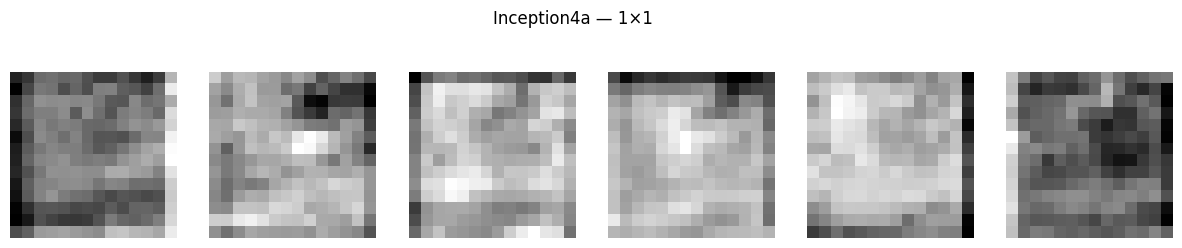

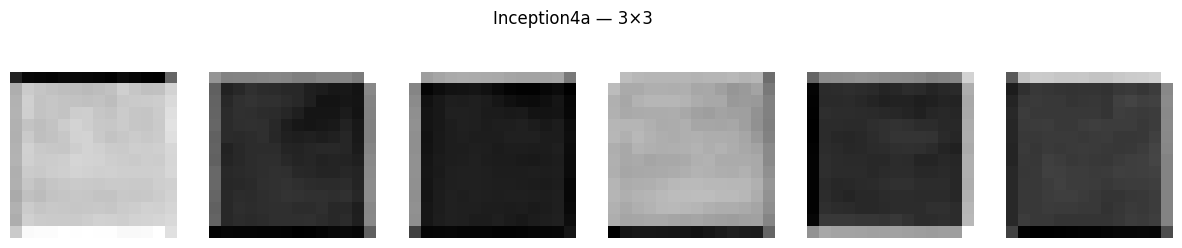

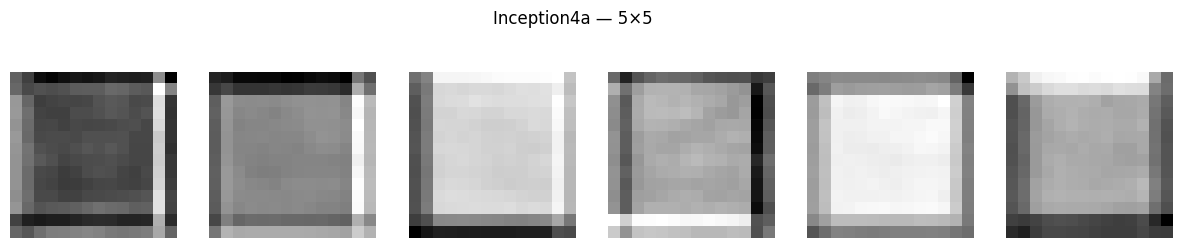

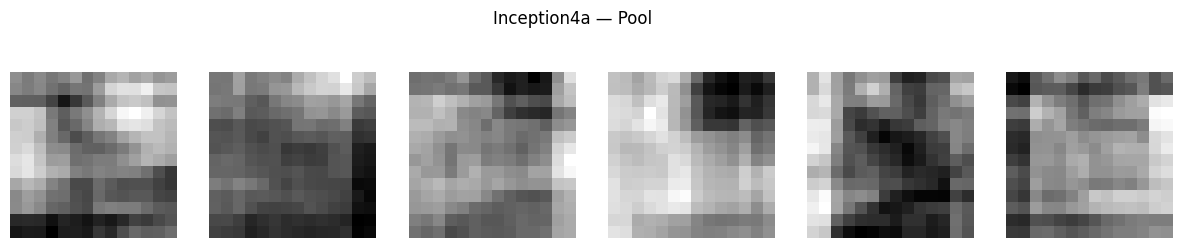

In [75]:
show_feature_maps(activations["1x1"], "Inception4a — 1×1")
show_feature_maps(activations["3x3"], "Inception4a — 3×3")
show_feature_maps(activations["5x5"], "Inception4a — 5×5")
show_feature_maps(activations["pool"], "Inception4a — Pool")

In [76]:
for h in hooks:
    h.remove()

### Robustness Experiments

In [78]:
def spatial_shift(x, dx=0, dy=0):
    """
    x: (1, C, H, W)
    dx: horizontal shift (+right, -left)
    dy: vertical shift (+down, -up)
    """
    B, C, H, W = x.shape
    pad_l = max(dx, 0)
    pad_r = max(-dx, 0)
    pad_t = max(dy, 0)
    pad_b = max(-dy, 0)

    x = F.pad(x, (pad_l, pad_r, pad_t, pad_b))
    x = x[:, :, pad_b:pad_b+H, pad_r:pad_r+W]
    return x


In [79]:
def register_inception_hooks(model, block_name="inception4a"):
    activations = {}

    block = dict(model.named_modules())[block_name]

    def save(name):
        def hook(_, __, output):
            activations[name] = output.detach()
        return hook

    block.convx1.register_forward_hook(save("1x1"))
    block.convx3.register_forward_hook(save("3x3"))
    block.convx5.register_forward_hook(save("5x5"))
    block.convxp1.register_forward_hook(save("pool"))

    return activations

In [80]:
def mask_branches(acts, mode):
    masked = {}

    for k, v in acts.items():
        if mode == "normal":
            masked[k] = v
        elif mode == "no_5x5" and k == "5x5":
            masked[k] = torch.zeros_like(v)
        elif mode == "no_pool" and k == "pool":
            masked[k] = torch.zeros_like(v)
        elif mode == "no_1x1" and k == "1x1":
            masked[k] = torch.zeros_like(v)
        elif mode == "only_pool":
            masked[k] = v if k == "pool" else torch.zeros_like(v)
        else:
            masked[k] = v

    return masked

In [81]:
def cosine_sim(a, b):
    return F.cosine_similarity(a.flatten(), b.flatten(), dim=0).item()

def activation_stats(t):
    return {
        "mean": t.mean().item(),
        "spatial_var": t.var(dim=(2,3)).mean().item(),
        "channel_var": t.var(dim=1).mean().item()
    }

In [91]:
def phase3_experiment(
    model,
    image,          # (1,3,224,224)
    device,
    shifts,
    block_name="inception4a"
):
    model.eval()
    results = defaultdict(dict)

    # Register hooks
    acts = register_inception_hooks(model, block_name)

    with torch.no_grad():
        # --- Baseline ---
        out = model(image.to(device))
        base_logits = out[0] if isinstance(out, tuple) else out
        base_probs = F.softmax(base_logits, dim=1)

        for shift_name, (dx, dy) in shifts.items():
            x = spatial_shift(image, dx, dy).to(device)

            # Normal forward
            out = model(x)
            logits = out[0] if isinstance(out, tuple) else out
            probs = F.softmax(logits, dim=1)

            results[shift_name]["logit_cos"] = cosine_sim(base_logits, logits)
            results[shift_name]["entropy"] = (-probs * probs.log()).sum().item()
            results[shift_name]["pred"] = probs.argmax(dim=1).item()

            # Branch stats
            for b, t in acts.items():
                results[shift_name][f"{b}_stats"] = activation_stats(t)

            # --- Ablations ---
            for mode in ["no_5x5", "no_pool", "no_1x1", "only_pool"]:
                masked = mask_branches(acts, mode)
                concat = torch.cat(
                    [masked["1x1"], masked["3x3"], masked["5x5"], masked["pool"]],
                    dim=1
                )

                # Pass through rest of network manually
                out = concat
                out = model.inception4b(out)
                out = model.inception4c(out)
                out = model.inception4d(out)
                out = model.inception4e(out)
                out = model.mpool(out)
                out = model.inception5a(out)
                out = model.inception5b(out)
                out = model.fpool(out)
                out = model.flatten(out)
                out = model.fc(out)

                results[shift_name][f"{mode}_cos"] = cosine_sim(base_logits, out)

    return results

In [92]:
shifts = {
    "orig": (0,0),
    "dx+4": (4,0),
    "dx-4": (-4,0),
    "dy+4": (0,4),
    "dy-4": (0,-4),
    "dx+8": (8,0),
    "dy+8": (0,8),
}

# grab exactly one image-label pair
val_image, val_label = test_dataset[0]
val_image = val_image.unsqueeze(0).to(device)

results = phase3_experiment(
    model=model,
    image=val_image,
    device=device,
    shifts=shifts
)

In [93]:
results

defaultdict(dict,
            {'orig': {'logit_cos': 1.0,
              'entropy': 2.3017165660858154,
              'pred': 2,
              '1x1_stats': {'mean': -0.0017821281217038631,
               'spatial_var': 2.4810155991872307e-06,
               'channel_var': 0.0009098349255509675},
              '3x3_stats': {'mean': 0.00139210547786206,
               'spatial_var': 1.7820721041061915e-05,
               'channel_var': 0.0005251791444607079},
              '5x5_stats': {'mean': -0.0006847686017863452,
               'spatial_var': 1.8313776308787055e-05,
               'channel_var': 0.0009422970470041037},
              'pool_stats': {'mean': 0.0013837578007951379,
               'spatial_var': 2.313607637915993e-06,
               'channel_var': 0.0007883793441578746},
              'no_5x5_cos': 1.0,
              'no_pool_cos': 1.0,
              'no_1x1_cos': 1.0,
              'only_pool_cos': 0.9999998807907104},
             'dx+4': {'logit_cos': 0.999999940395355

In [96]:
# 1. Register hooks
acts = {}
block = dict(model.named_modules())["inception4a"]

def save(name):
    def hook(_, __, output):
        acts[name] = output.detach().cpu()
    return hook

block.convx1.register_forward_hook(save("1x1"))
block.convx3.register_forward_hook(save("3x3"))
block.convx5.register_forward_hook(save("5x5"))
block.convxp1.register_forward_hook(save("pool"))

# 2. Run ONE forward pass
model.eval()
with torch.no_grad():
    _ = model(val_image)

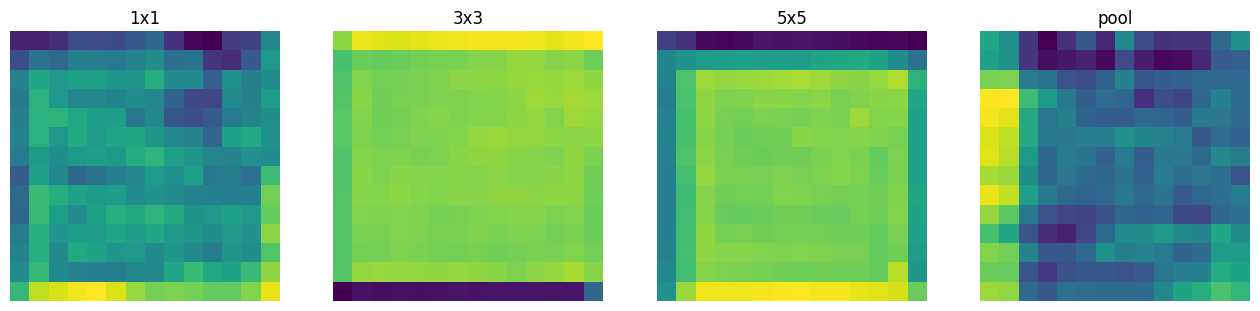

In [97]:
def show_branch_maps(acts):
    fig, axs = plt.subplots(1, 4, figsize=(16,4))
    for ax, (name, t) in zip(axs, acts.items()):
        # mean over channels → spatial map
        ax.imshow(t.mean(dim=1)[0], cmap="viridis")
        ax.set_title(name)
        ax.axis("off")
    plt.show()

show_branch_maps(acts)

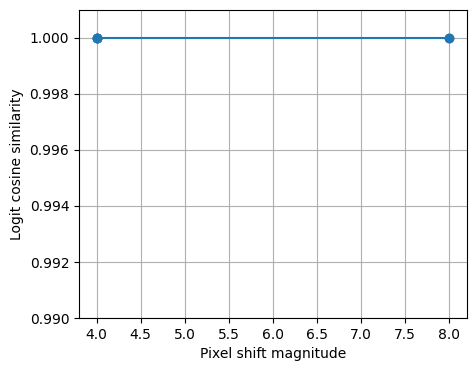

In [99]:
xs = []
ys = []

for k, v in results.items():
    if k == "orig":
        continue
    
    # extract signed integer using regex
    shift = int(re.findall(r"[-+]?\d+", k)[0])
    xs.append(abs(shift))
    ys.append(v["logit_cos"])

plt.figure(figsize=(5,4))
plt.plot(xs, ys, marker="o")
plt.xlabel("Pixel shift magnitude")
plt.ylabel("Logit cosine similarity")
plt.ylim(0.99, 1.001)
plt.grid(True)
plt.show()

## Model Training

In [101]:
train_losses, train_top1_errors, train_top3_errors, train_top5_errors, \
test_losses, test_top1_errors, test_top3_errors, test_top5_errors = train(
    num_epochs=12,
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader, 
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    update_freq=10
)

Epochs:   0%|          | 0/12 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]

...

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval:   0%|          | 0/62 [00:00<?, ?it/s]


✅ Done! Total: 34.2min | Final Val T1E: 91.00%


In [102]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}
torch.save(checkpoint, 'googlenet_20.pth')

## Analysis

### Phase 2 again

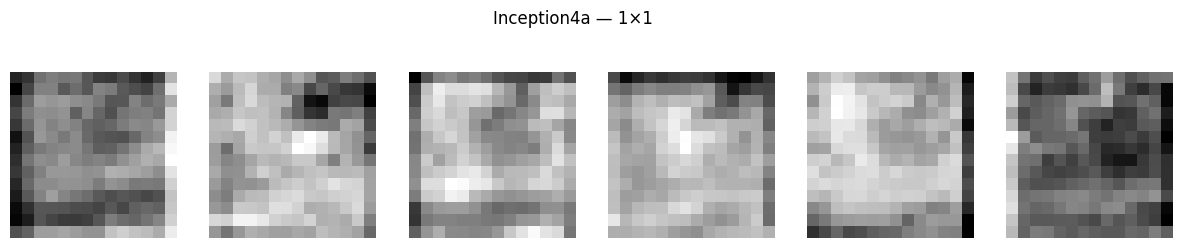

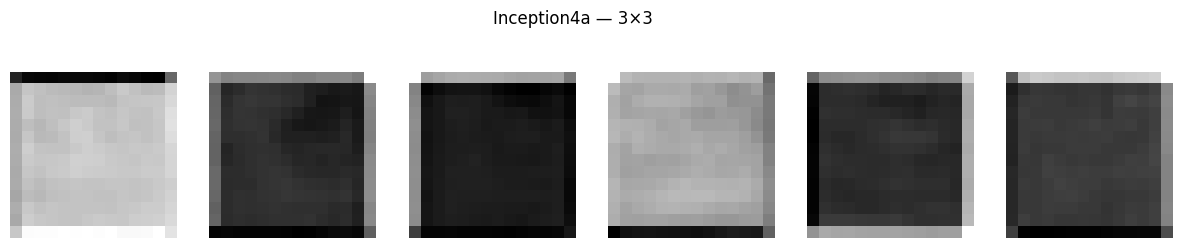

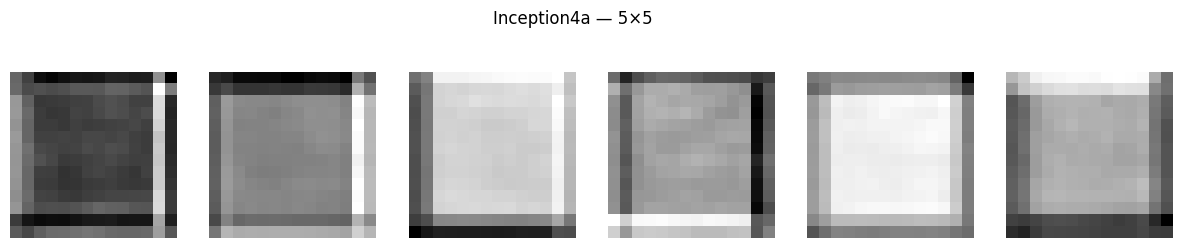

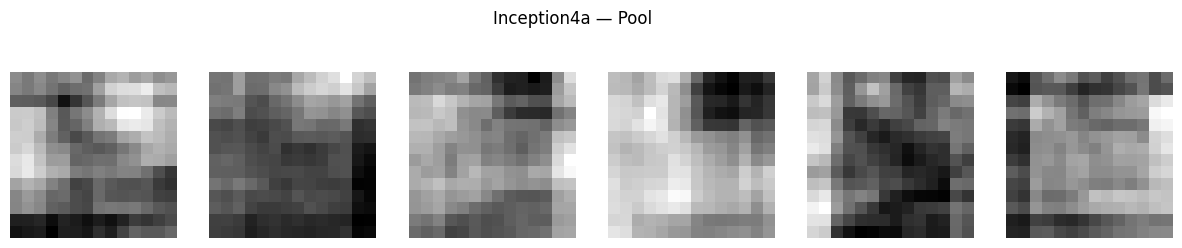

In [103]:
activations = {}

def save_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hooks = []
hooks.append(model.inception4a.convx1.register_forward_hook(save_activation("1x1")))
hooks.append(model.inception4a.convx3.register_forward_hook(save_activation("3x3")))
hooks.append(model.inception4a.convx5.register_forward_hook(save_activation("5x5")))
hooks.append(model.inception4a.convxp1.register_forward_hook(save_activation("pool")))

model.eval()

img, _ = next(iter(test_dataloader))
img = img[0:1].to(device)

with torch.no_grad():
    _ = model(img)   # normal forward

def show_feature_maps(tensor, title, n=6):
    maps = tensor[0][:n].cpu()
    fig, axes = plt.subplots(1, n, figsize=(15,3))
    fig.suptitle(title)
    for i in range(n):
        axes[i].imshow(maps[i], cmap="gray")
        axes[i].axis("off")
    plt.show()

show_feature_maps(activations["1x1"], "Inception4a — 1×1")
show_feature_maps(activations["3x3"], "Inception4a — 3×3")
show_feature_maps(activations["5x5"], "Inception4a — 5×5")
show_feature_maps(activations["pool"], "Inception4a — Pool")

### Phase 3 again

In [105]:
shifts = {
    "orig": (0,0),
    "dx+4": (4,0),
    "dx-4": (-4,0),
    "dy+4": (0,4),
    "dy-4": (0,-4),
    "dx+8": (8,0),
    "dy+8": (0,8),
}

# grab exactly one image-label pair
val_image, val_label = test_dataset[0]
val_image = val_image.unsqueeze(0).to(device)

results = phase3_experiment(
    model=model,
    image=val_image,
    device=device,
    shifts=shifts
)
results

defaultdict(dict,
            {'orig': {'logit_cos': 0.9999999403953552,
              'entropy': 2.3018486499786377,
              'pred': 2,
              '1x1_stats': {'mean': -0.0018962239846587181,
               'spatial_var': 2.6746461116999853e-06,
               'channel_var': 0.0009119288297370076},
              '3x3_stats': {'mean': 0.0013159136287868023,
               'spatial_var': 1.7915546777658165e-05,
               'channel_var': 0.0005225669010542333},
              '5x5_stats': {'mean': -0.0006842313450761139,
               'spatial_var': 1.8195449229096994e-05,
               'channel_var': 0.000939873862080276},
              'pool_stats': {'mean': 0.0013951181899756193,
               'spatial_var': 2.4282037429657066e-06,
               'channel_var': 0.0007875256706029177},
              'no_5x5_cos': 1.0,
              'no_pool_cos': 1.0,
              'no_1x1_cos': 0.9999999403953552,
              'only_pool_cos': 0.9999999403953552},
             'dx+4':

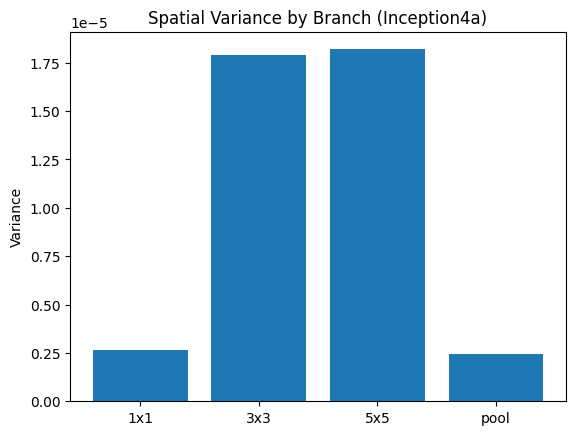

In [106]:
branches = ["1x1", "3x3", "5x5", "pool"]
spatial_vars = [
    results["orig"]["1x1_stats"]["spatial_var"],
    results["orig"]["3x3_stats"]["spatial_var"],
    results["orig"]["5x5_stats"]["spatial_var"],
    results["orig"]["pool_stats"]["spatial_var"],
]

plt.bar(branches, spatial_vars)
plt.title("Spatial Variance by Branch (Inception4a)")
plt.ylabel("Variance")
plt.show()

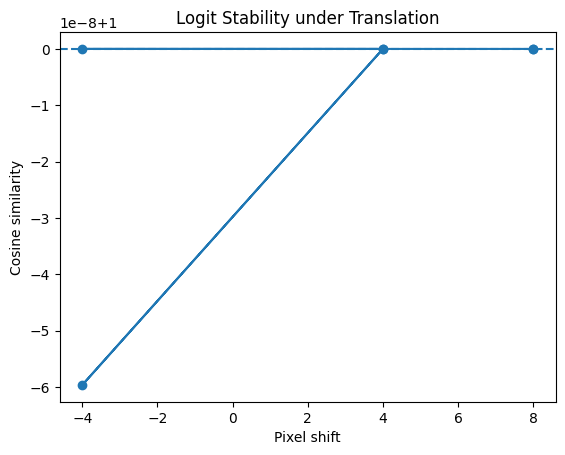

In [107]:
xs, ys = [], []
for k,v in results.items():
    if k != "orig":
        shift = int(k.split("+")[-1]) if "+" in k else -int(k.split("-")[-1])
        xs.append(shift)
        ys.append(v["logit_cos"])

plt.plot(xs, ys, marker="o")
plt.axhline(1.0, linestyle="--")
plt.title("Logit Stability under Translation")
plt.xlabel("Pixel shift")
plt.ylabel("Cosine similarity")
plt.show()

In [109]:
acts = {}
def inception_hook(module, inp, out):
    # out is concatenated: [1x1 | 3x3 | 5x5 | pool]
    x1 = module.x1
    x3 = module.x3
    x5 = module.x5
    pp = module.pp

    acts["1x1"]  = out[:, :x1]
    acts["3x3"]  = out[:, x1:x1+x3]
    acts["5x5"]  = out[:, x1+x3:x1+x3+x5]
    acts["pool"] = out[:, x1+x3+x5:]

In [111]:
hook = model.inception4a.register_forward_hook(inception_hook)
model.eval()
with torch.no_grad():
    logits = model(val_image.to(device))
print(acts.keys())

dict_keys(['1x1', '3x3', '5x5', 'pool'])


In [117]:
def cosine(a, b):
    a_flat = F.adaptive_avg_pool2d(a, (1,1)).flatten(1)  # (B, C_a)
    b_flat = F.adaptive_avg_pool2d(b, (1,1)).flatten(1)  # (B, C_b)
    
    min_c = min(a_flat.size(1), b_flat.size(1))
    a_norm = F.normalize(a_flat[:, :min_c], p=2, dim=1)
    b_norm = F.normalize(b_flat[:, :min_c], p=2, dim=1)
    
    return (a_norm * b_norm).sum(dim=1)  # (B,)

def branch_stats(x):
    return {
        "mean": x.mean().item(),
        "spatial_var": x.var(dim=[2,3]).mean().item(),
        "channel_var": x.var(dim=1).mean().item()
    }

In [118]:
results_A = {}

for name, feat in acts.items():
    results_A[name] = branch_stats(feat)
pairs = {}
keys = list(acts.keys())

for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        a, b = keys[i], keys[j]
        pairs[f"{a} vs {b}"] = cosine(acts[a], acts[b])

In [120]:
print("=== Branch Statistics ===")
for k,v in results_A.items():
    print(f"{k}: {v}")

print("\n=== Pairwise Cosine Similarity ===")
for k, v in pairs.items():
    print(f"{k}: {v.mean().item():.4f}")  # Average if batched

=== Branch Statistics ===
1x1: {'mean': 0.011796231381595135, 'spatial_var': 1.3131636933394475e-06, 'channel_var': 0.00025971169816330075}
3x3: {'mean': 0.010101166553795338, 'spatial_var': 8.962206266005524e-06, 'channel_var': 0.00018169978284277022}
5x5: {'mean': 0.012585474178195, 'spatial_var': 8.302608875965234e-06, 'channel_var': 0.0003198079648427665}
pool: {'mean': 0.012191236950457096, 'spatial_var': 1.2636689916689647e-06, 'channel_var': 0.00028280005790293217}

=== Pairwise Cosine Similarity ===
1x1 vs 3x3: 0.4771
1x1 vs 5x5: 0.2644
1x1 vs pool: 0.2304
3x3 vs 5x5: 0.4360
3x3 vs pool: 0.4060
5x5 vs pool: 0.4278


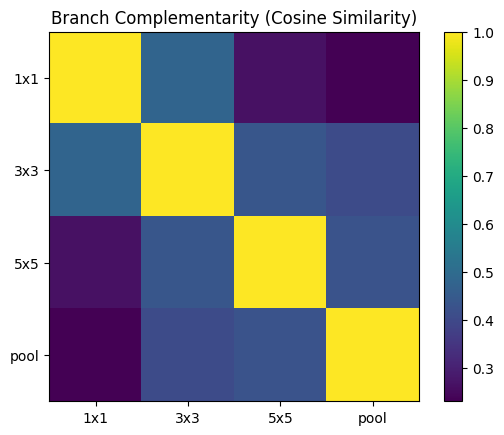

In [121]:
names = list(acts.keys())
n = len(names)
M = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        if i == j:
            M[i,j] = 1.0
        else:
            M[i,j] = cosine(acts[names[i]], acts[names[j]])

plt.imshow(M, cmap="viridis")
plt.colorbar()
plt.xticks(range(n), names)
plt.yticks(range(n), names)
plt.title("Branch Complementarity (Cosine Similarity)")
plt.show()

In [122]:
hook.remove()

In [123]:
def plot_loss(train_losses, test_losses, save_path, label):
    epochs_range = range(1, len(train_losses) + 1)
    plt.plot(epochs_range, train_losses, 'b-o', label=f"Train {label}", linewidth=2, markersize=6)
    plt.plot(epochs_range, test_losses, 'r-s', label=f"Test {label}", linewidth=2, markersize=6)
    plt.xlabel('Epoch')
    plt.ylabel(label)
    plt.title(f"Train and Test {label}", fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)  # dpi=300 gives high-quality image

    plt.show()

def plot_accuracy(train_accuracies, test_accuracies, save_path):
    epochs_range = range(1, len(train_accuracies) + 1)
    plt.plot(epochs_range, train_accuracies, 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
    plt.plot(epochs_range, test_accuracies, 'r-s', label='Test Accuracy', linewidth=2, markersize=6)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Test Accuracy', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)  # dpi=300 gives high-quality image

    plt.show()
    
def plot_accuracy_improvement(test_accuracies, save_path):
    epochs_range = range(1, len(test_accuracies) + 1)
    improvement = - np.array(test_accuracies) + test_accuracies[0]
    plt.bar(epochs_range, improvement, alpha=0.7, color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy Improvement (%)')
    plt.title('Test Accuracy Improvement', fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
     # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)  # dpi=300 gives high-quality image

    plt.show()

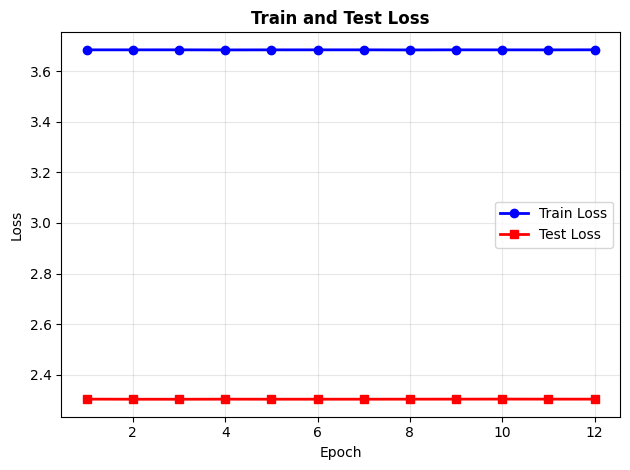

In [124]:
plot_loss(train_losses=train_losses, test_losses=test_losses, save_path="loss.png", label="Loss")

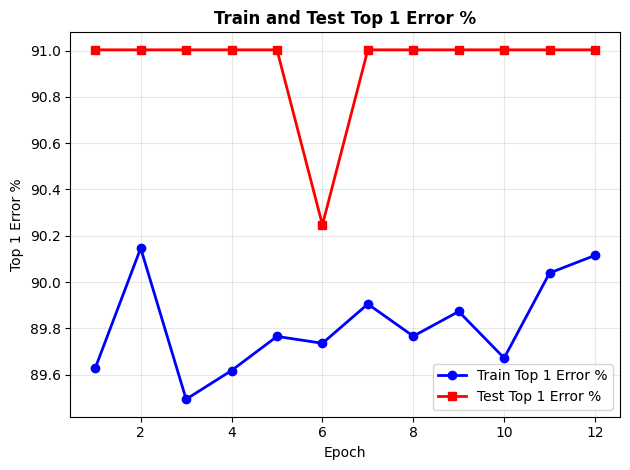

In [125]:
plot_loss(train_losses=train_top1_errors, test_losses=test_top1_errors, save_path="top1_errors.png", label="Top 1 Error %")

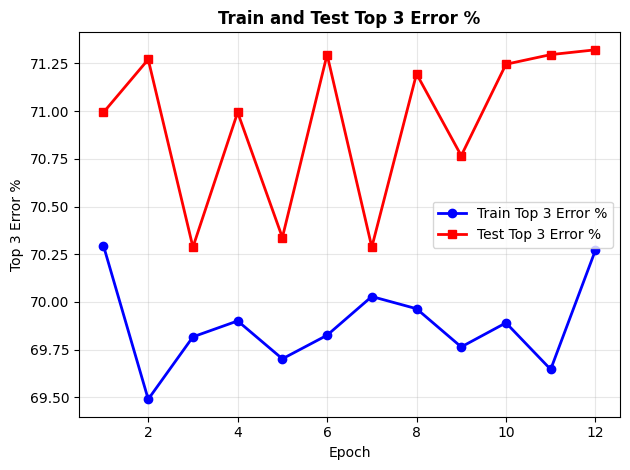

In [126]:
plot_loss(train_losses=train_top3_errors, test_losses=test_top3_errors, save_path="top3_errors.png", label="Top 3 Error %")

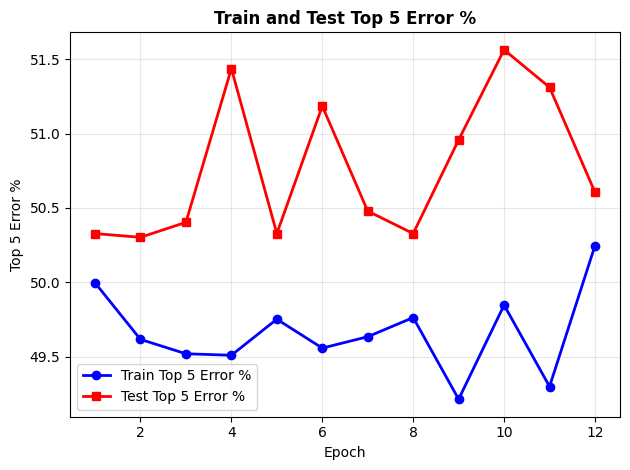

In [127]:
plot_loss(train_losses=train_top5_errors, test_losses=test_top5_errors, save_path="top5_errors.png", label="Top 5 Error %")